In [ ]:
#========================================================================
# Name: machine-learning-german-credit-data.py
#
# Date: 06/04/2026
#
# Author: MT
#
# Description: South German Credit Data Machine Learning Pipeline
#
# Dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit
#
# Step 0: Imports
# Step 1: Load Data
# Step 2: Plot Response
# Step 3: Plot Numeric Features
# Step 4: Plot Categorical Features
# Step 5: Feature Importance (WoE, IV, Gini)
# Step 6: Feature Clustering
# Step 7: Correlation
# Step 8: Prepare for Modelling
# Step 9: Modelling
# Step 10: Collate Results
#
#========================================================================

In [4]:
#========================================================================
# Step 0: Imports

# General
import pandas as pd
import numpy as np
import copy

pd.set_option('display.max_columns', 10000)
pd.set_option('display.max_rows', 10000)
pd.options.display.float_format = '{:,.2f}'.format

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier  
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Explainability & Encoding
import shap
import category_encoders as ce
shap.initjs()

# Model Performance & Clustering
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Helper Functions
def gini_group(y_true=None, y_score=None, group=None, round_decimals=2):
    """Calculate Gini for each group"""
    levels = group.unique()
    values = []
    for this_level in levels:
        this_y_true = y_true[group == this_level]
        this_y_score = y_score[group == this_level]
        values.append(roc_auc_score(y_true=this_y_true, y_score=this_y_score) * 2 - 1)
    return pd.DataFrame({'group': levels, 'Gini': values}).round(round_decimals)

def gini(y_true, y_pred, decimals=4):
    """Calculate the Gini coefficient based on true and predicted values."""
    return round(float(roc_auc_score(y_true, y_pred) * 2 - 1), decimals)

def roc_curve_group(y_true=None, y_score=None, group=None, round_decimals=2):
    """Calculate ROC Curve for each group"""
    levels = group.unique()
    prep_auc = pd.DataFrame()
    for this_level in levels:
        this_y_true = y_true[group == this_level]
        this_y_score = y_score[group == this_level]
        fpr, tpr, _ = roc_curve(y_true=this_y_true, y_score=this_y_score)
        t1 = pd.DataFrame({'Model': this_level, 'fpr': fpr, 'tpr': tpr})
        prep_auc = pd.concat([prep_auc, t1], axis=0)
    return prep_auc.round(round_decimals)

def bin_feature(y_true, feature, num_bins=4):
    """Bin a feature based on the target variable."""
    binned_feature = None
    if isinstance(feature.values[0], (int, float, np.number)):
        vals = feature[y_true == 1]
        _, bins = pd.qcut(vals, q=num_bins, duplicates='drop', retbins=True)
        bins[0] = -99999
        bins[-1] = 99999
        binned_feature = pd.cut(feature, bins=bins)
    elif isinstance(feature.values[0], str):
        binned_feature = feature
    return binned_feature

def woe_iv_calc(y_true, feature, num_bins=4):
    """Calculate Weight of Evidence (WoE) and Information Value (IV)."""
    this_binned_feature = bin_feature(y_true, feature, num_bins=num_bins)
    woe_table = pd.crosstab(index=this_binned_feature, columns=y_true)
    woe_table['Total'] = woe_table[0] + woe_table[1]
    woe_table['P0'] = woe_table[0] / woe_table[0].sum()
    woe_table['P1'] = woe_table[1] / woe_table[1].sum()
    woe_table['woe'] = np.log(woe_table['P1'] / woe_table['P0'])
    woe_table['iv_comp'] = woe_table['woe'] * (woe_table['P1'] - woe_table['P0'])
    iv = woe_table['iv_comp'].sum()
    return [woe_table, iv]
#========================================================================

In [6]:
#========================================================================
# Step 1: Load Data
df = pd.read_csv('german_credit.csv')

# Bad Flag
df['bad_flag'] = np.where(df['credit_risk'] == 'bad', 1, 0)
df.drop(columns=['credit_risk'], inplace=True)

print('--------------------')
print('## Information ##')
df.info()
print('--------------------\n')
#========================================================================

--------------------
## Information ##
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   str  
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   str  
 6   employment_duration      1000 non-null   str  
 7   installment_rate         1000 non-null   str  
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  present_residence        1000 non-null   str  
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000

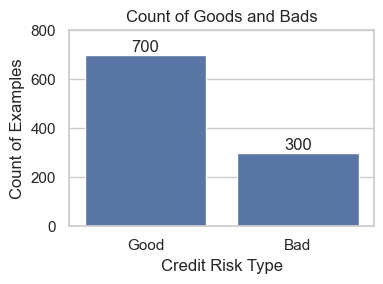

In [7]:
#========================================================================
# Step 2: Plot Response
df_smry = df['bad_flag'].value_counts().reset_index()
df_smry['bad_flag'] = df_smry['bad_flag'].map({0: 'Good', 1: 'Bad'})

plt.figure(figsize=(4, 3))
ax = sns.barplot(data=df_smry, x='bad_flag', y='count')
ax.bar_label(ax.containers[0])
ax.set_xlabel('Credit Risk Type')
ax.set_ylabel('Count of Examples')
plt.ylim(0, 800) 
plt.title('Count of Goods and Bads')
plt.tight_layout()
plt.savefig("credit-data-count-goods-bads.png", dpi=300)
plt.show()
#========================================================================

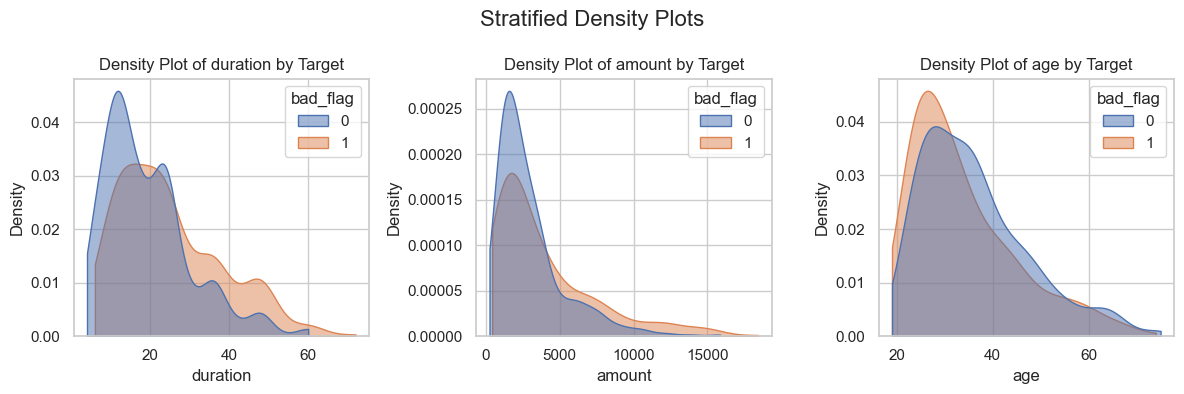

In [8]:
#========================================================================
# Step 3: Plot Numeric Features
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('bad_flag')
num_numeric_cols = len(numeric_cols)

fig, axes = plt.subplots(1, num_numeric_cols, figsize=(12, 4))
for i, this_var in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=this_var, hue='bad_flag', fill=True, 
                common_norm=False, cut=0, alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Density Plot of {this_var} by Target', fontsize=12)
fig.suptitle('Stratified Density Plots', fontsize=16)
plt.tight_layout()
plt.savefig("credit-data-numeric-features.png", dpi=300)
plt.show()
#========================================================================

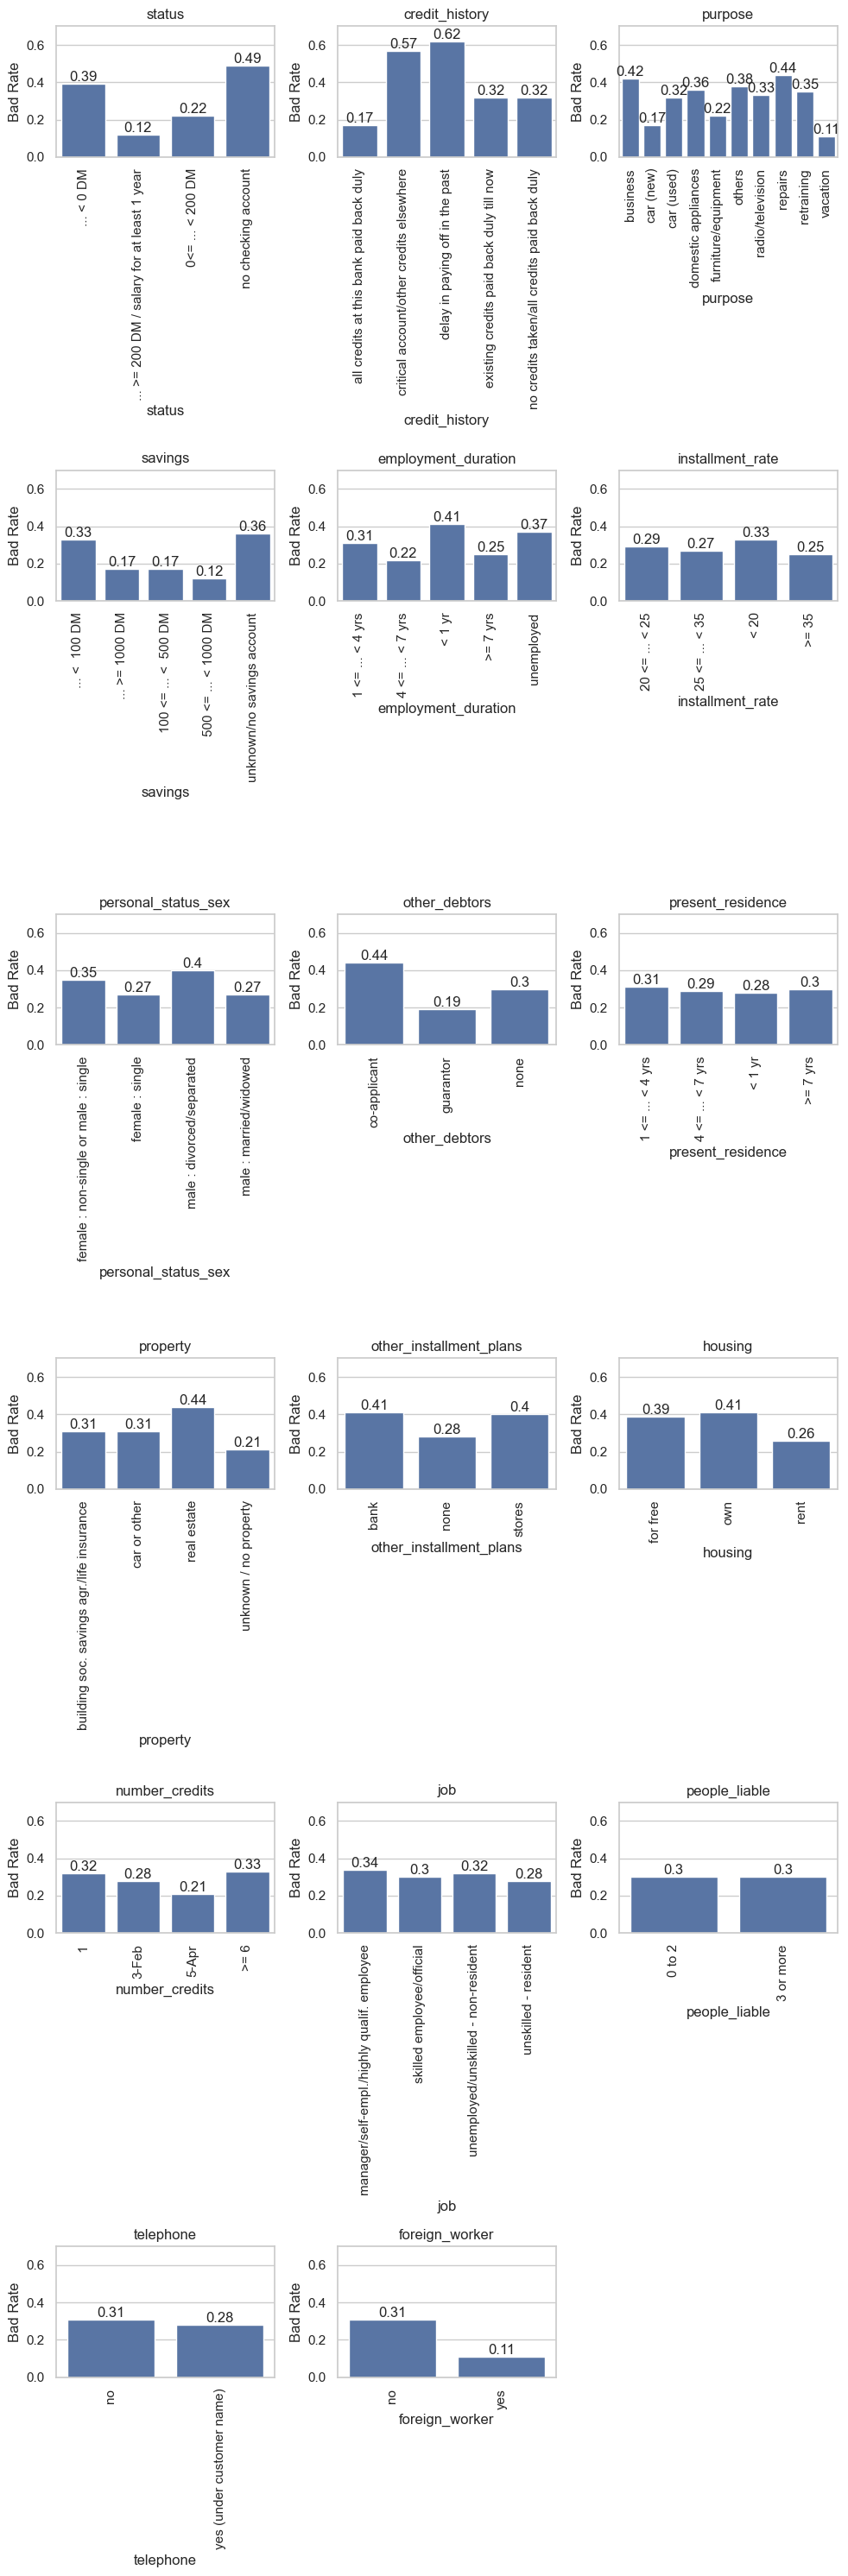

In [9]:
#========================================================================
# Step 4: Plot Categorical Features

categorical_cols = df.select_dtypes(exclude=[np.number]).columns
num_categorical_cols = len(categorical_cols)

cols = 3
rows = (num_categorical_cols + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df_smry = df[['bad_flag', col]].groupby(col).mean().reset_index().round(2)
    ax = axes[i]
    sns.barplot(data=df_smry, x=col, y='bad_flag', ax=ax)
    ax.bar_label(ax.containers[0])
    ax.set_xlabel(col)
    ax.set_ylabel('Bad Rate')
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylim(0, 0.7)
    ax.set_title(f'{col}')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("credit-data-categorical-features.png", dpi=300)
plt.show()
#========================================================================

--------------------
## Feature Importance ##
                    feature   IV  Gini
0                    status 0.67  0.42
1            credit_history 0.29  0.25
2                   savings 0.20  0.20
3                  duration 0.18  0.22
4                   purpose 0.17  0.22
5                  property 0.11  0.17
6       employment_duration 0.09  0.16
7                       age 0.09  0.15
8                   housing 0.09  0.14
9                    amount 0.07  0.14
10  other_installment_plans 0.06  0.10
11      personal_status_sex 0.04  0.10
12           foreign_worker 0.04  0.03
13            other_debtors 0.03  0.05
14         installment_rate 0.03  0.09
15           number_credits 0.01  0.05
16                      job 0.01  0.04
17                telephone 0.01  0.04
18        present_residence 0.00  0.03
19            people_liable 0.00  0.00
--------------------



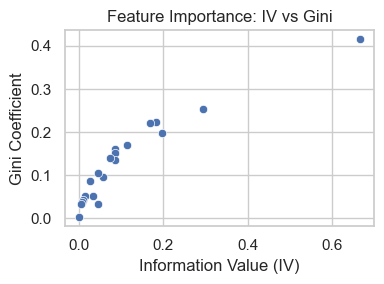

In [10]:
#========================================================================
# Step 5: Feature Importance (WoE, IV, Gini)

all_cols = df.drop('bad_flag', axis=1).columns.to_list()

# Binned dataset
df_binned = pd.DataFrame(index=df.index)
for col in all_cols:
    df_binned.loc[:, [col]] = bin_feature(df['bad_flag'], df[col], num_bins=4)

# WoE Encoding
encoder = ce.WOEEncoder(cols=all_cols, regularization=0)
encoder.fit(df_binned[all_cols], df['bad_flag'])
df_binned2 = encoder.transform(df_binned[all_cols])
df_binned2['bad_flag'] = df['bad_flag']

# Numeric Dataset
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.to_list()
df_binned3 = pd.concat([df[num_cols], df_binned2[cat_cols]], axis=1)
df_binned3 = df_binned3[df.columns.to_list()]

# Calculate and print IV/Gini
all_ivs, all_ginis = [], []
for col in all_cols:
    woe_table, iv = woe_iv_calc(df['bad_flag'], df[col], num_bins=4)
    gini_val = gini(df_binned2['bad_flag'], df_binned2[col], decimals=4)
    all_ivs.append(iv)
    all_ginis.append(gini_val)

importance = pd.DataFrame({'feature': all_cols, 'IV': all_ivs, 'Gini': all_ginis}) \
    .sort_values('IV', ascending=False).reset_index(drop=True)

print('--------------------')
print('## Feature Importance ##')
print(importance)
print('--------------------\n')

plt.figure(figsize=(4, 3))
sns.scatterplot(data=importance, x='IV', y='Gini')
plt.title('Feature Importance: IV vs Gini')
plt.xlabel('Information Value (IV)')
plt.ylabel('Gini Coefficient')
plt.tight_layout()
plt.savefig("credit-data-feature-importance.png", dpi=300)
plt.show()

#========================================================================

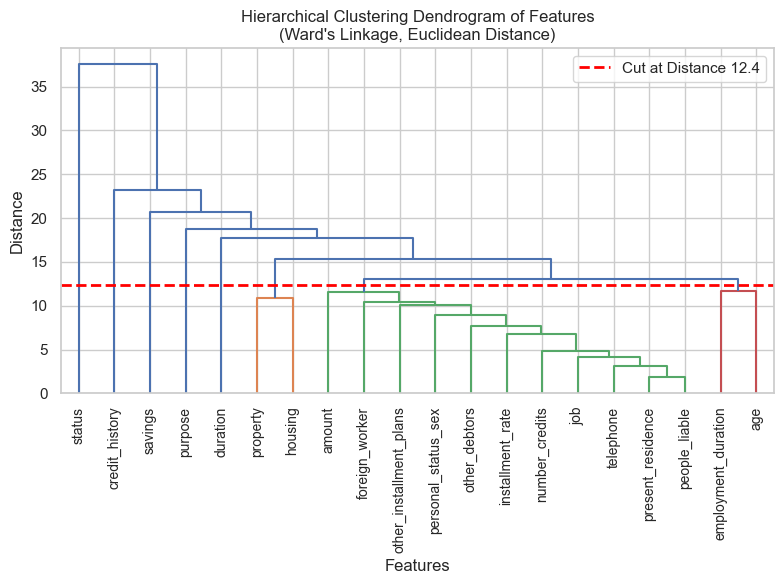

In [11]:
#========================================================================
# Step 6: Feature Clustering

features = df_binned2.drop('bad_flag', axis=1)
Z = linkage(features.T, method='ward', metric='euclidean')

t = 12.4
plt.figure(figsize=(8, 6))
dendrogram(Z, labels=features.columns, leaf_rotation=90, leaf_font_size=10, color_threshold=t)
plt.axhline(y=t, color='red', linestyle='--', linewidth=2, label=f'Cut at Distance {t}')
plt.title('Hierarchical Clustering Dendrogram of Features\n(Ward\'s Linkage, Euclidean Distance)')
plt.xlabel('Features')
plt.ylabel('Distance')
plt.legend()
plt.tight_layout()
plt.savefig(f"credit-data-feature-clustering-dendrogram-cut-{t}.png", dpi=300)
plt.show()

# Get the dendrogram leaf order
result = dendrogram(Z, labels=features.columns, no_plot=True)
leaf_order = result['leaves']
ordered_features = result['ivl']

clusters = fcluster(Z, t=12.4, criterion='distance')
ordered_clusters = clusters[leaf_order]
df_clusters = pd.DataFrame({'feature': ordered_features, 'cluster': ordered_clusters})
#========================================================================

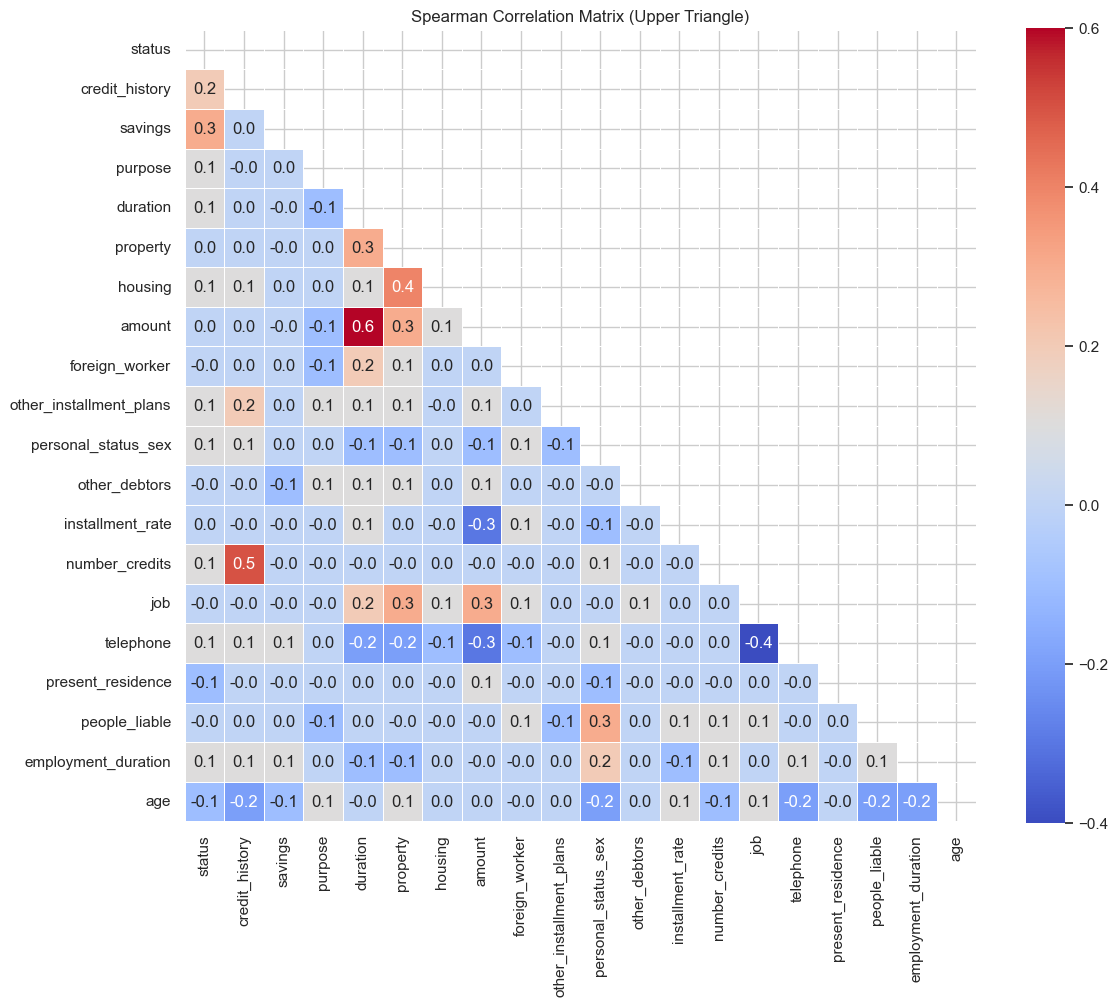

In [12]:
#========================================================================
# Step 7: Correlation

cols = df_clusters['feature']
correl = df_binned3[cols].corr(method='spearman').round(1)
mask = np.triu(np.ones_like(correl, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(correl, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.1f', square=True, mask=mask)
plt.title('Spearman Correlation Matrix (Upper Triangle)')
plt.tight_layout()
plt.savefig("credit-data-correlation-matrix.png", dpi=300)
plt.show()
#========================================================================

In [13]:
#========================================================================
# Step 8: Prepare for Modelling

X = df_binned3.drop(['bad_flag'], axis=1)
y = df_binned3['bad_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=19)
#========================================================================

In [25]:
#========================================================================
# Step 9: Modelling

# XGBoost
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)
pred_xgb = pd.DataFrame({'model': 'xgb', 'target': y_test, 'pred': model_xgb.predict_proba(X_test)[:, 1]})

# LightGBM
model_lgb = LGBMClassifier(verbose=-1)
model_lgb.fit(X_train, y_train)
pred_lgb = pd.DataFrame({'model': 'lgb', 'target': y_test, 'pred': model_lgb.predict_proba(X_test)[:, 1]})

# CatBoost
model_cat = CatBoostClassifier(verbose=False)
model_cat.fit(X_train, y_train)
pred_cat = pd.DataFrame({'model': 'cat', 'target': y_test, 'pred': model_cat.predict_proba(X_test)[:, 1]})

# Random Forest
model_rfc = RandomForestClassifier()
model_rfc.fit(X_train, y_train)
pred_rfc = pd.DataFrame({'model': 'rf', 'target': y_test, 'pred': model_rfc.predict_proba(X_test)[:, 1]})

# Logistic Regression
model_lrg = LogisticRegression(l1_ratio=0, solver='newton-cg')
model_lrg.fit(X_train, y_train)
pred_lrg = pd.DataFrame({'model': 'lr', 'target': y_test, 'pred': model_lrg.predict_proba(X_test)[:, 1]})

# Naive Bayes
model_nb = GaussianNB()
model_nb.fit(X_train,  y_train)
pred_nb = pd.DataFrame({'model': 'nb', 'target': y_test, 'pred': model_nb.predict_proba(X_test)[:, 1]})

# K-Nearest Neighbours
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
pred_knn = pd.DataFrame({'model': 'knn', 'target': y_test, 'pred': model_knn.predict_proba(X_test)[:, 1]})

# Support Vector Machine
model_svc = SVC(probability=True)
model_svc.fit(X_train, y_train)
pred_svc = pd.DataFrame({'model': 'svc', 'target': y_test, 'pred': model_svc.predict_proba(X_test)[:, 1]})

# Neural Network (Multilayer Perceptron)
model_mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000)
model_mlp.fit(X_train, y_train)
pred_mlp = pd.DataFrame({'model': 'nn', 'target': y_test, 'pred': model_mlp.predict_proba(X_test)[:, 1]})

# Linear Discriminant Analysis
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
pred_lda = pd.DataFrame({'model': 'lda', 'target': y_test, 'pred': model_lda.predict_proba(X_test)[:, 1]})
#========================================================================

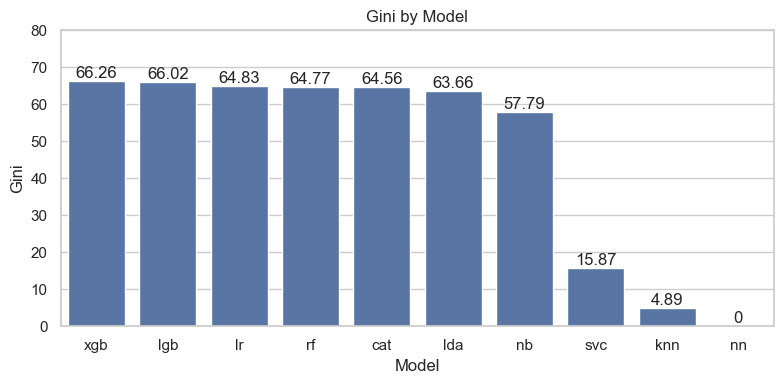

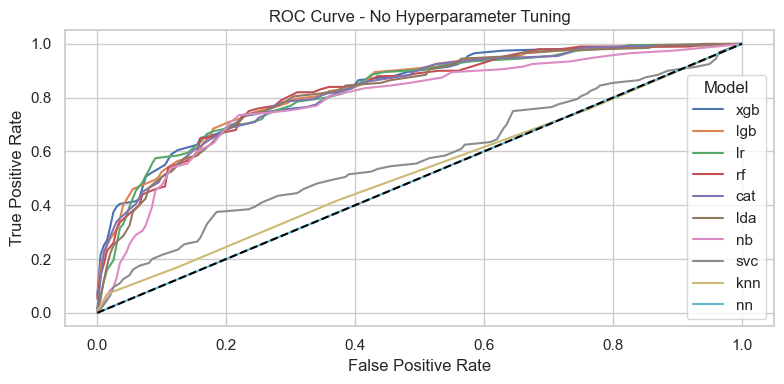

In [26]:
#========================================================================
# Step 10: Collate Results

# Join all predictions
pred = pd.concat([
    pred_xgb, pred_lgb, pred_cat, pred_rfc, pred_lrg, 
    pred_nb, pred_knn, pred_svc, pred_mlp, pred_lda
], axis=0).reset_index(drop=True)

# Gini Calculation
gini_df = gini_group(y_true=pred['target'], y_score=pred['pred'], group=pred['model'], round_decimals=4) \
          .sort_values('Gini', ascending=False).reset_index(drop=True).rename(columns={'index': 'ModelID'})
gini_df['Gini'] = gini_df['Gini'] * 100

# Gini Barplot
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=gini_df, y='Gini', x='group')
ax.bar_label(ax.containers[0])
plt.ylabel('Gini')
plt.xlabel('Model')
plt.ylim(0, 80)
plt.title('Gini by Model')
plt.tight_layout()
plt.savefig("credit-data-gini.png", dpi=300)
plt.show()

# ROC Curve
roc_curve_df = roc_curve_group(y_true=pred['target'], y_score=pred['pred'], group=pred['model'], round_decimals=6)
roc_curve_df2 = pd.merge(gini_df, roc_curve_df, left_on='group', right_on='Model', how='left')

plt.figure(figsize=(8, 4))
sns.lineplot(data=roc_curve_df2, x='fpr', y='tpr', hue='Model', errorbar=None)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - No Hyperparameter Tuning')
plt.tight_layout()
plt.savefig("credit-data-roc-curve.png", dpi=300)
plt.show()